# Descriptive Analysis: LitEval-Corpus

**Dataset:** Zhang, Zhao & Eger (2025). *How Good Are LLMs for Literary Translation, Really? Literary Translation Evaluation with Humans and LLMs.* NAACL 2025.
https://github.com/zhangr2021/LitMT_eval,  https://aclanthology.org/2025.naacl-long.548/

**Task:** MQM (Multidimensional Quality Metrics) human evaluation of literary MT vs. professionally published human translation, plus automatic-metric and LLM-judge (GEMBA-MQM) scoring of the same segments

**Language pairs:** German -> English, English -> German, German -> Chinese, English -> Chinese   

**Systems:** 9 MT systems (GPT-4o, DeepL, Google Translate, Qwen2-beta-7B-Chat, TowerInstruct-7B-v0.2, Llama-3-8B-Instruct, Gemma-1.1-7B-it, NLLB-200, M2M-100) plus the professionally published human translation(s) per book   

**Design:** 
- Paragraph-level parallel corpus of classic (1774–1927) and contemporary (2010–2024) published novels, each with 1–3 human translations
- Trained student annotators produced MQM error-span annotations (accuracy/fluency/style/terminology, severity, overall 1–7 rating) for every system's output on the same source paragraphs  

**Data:** 
- Full controlled-access corpus (real, untruncated source/target text, per-span MQM error annotations, inter-annotator agreement checks and automatic-metric outputs) is available locally at `data/LITEVAL-CORPUS/`
- Richer source than the public GitHub sample used for the corpus-wide overview below (`data/liteval_corpus/`, whose `metric_df.csv` truncates text to 20 characters for fair use)
- German -> English deep dive further down reads real paragraph text directly

In [1]:
# Load libraries
import os
import csv
import json
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

if os.path.basename(os.getcwd()) == 'data_description':
    os.chdir('..')

In [2]:
# Plotting parameters
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 11})

# Full local corpus (real text + annotations)
CORPUS = 'data/LITEVAL-CORPUS'

# Public GitHub sample (metric_df.csv, book metadata)
SAMPLE = 'data/liteval_corpus'

FIG = 'figures/data_description'

HT_COLOR = '#cb1f73'
SRC_COLOR = '#D8C3A5'
PAIR_ORDER = ['de-en', 'en-de', 'de-zh', 'en-zh']
PAIR_LABELS = {'de-en': 'German→English', 'en-de': 'English→German', 'de-zh': 'German→Chinese', 'en-zh': 'English→Chinese'}

MODEL_ORDER = ['translator', 'gpt4o', 'google translate', 'deepl', 'qwen2-beta-7b-chat', 'towerinstruct-7b-v0.2', 
               'meta-llama-3-8b-instruct', 'gemma-1.1-7b-it', 'nllb', 'm2m']


MODEL_LABELS = {
    'translator': 'Human translator', 'gpt4o': 'GPT-4o', 'google translate': 'Google Translate',
    'deepl': 'DeepL', 'qwen2-beta-7b-chat': 'Qwen2-beta-7B-Chat', 'towerinstruct-7b-v0.2': 'TowerInstruct-7B-v0.2',
    'meta-llama-3-8b-instruct': 'Llama-3-8B-Instruct', 'gemma-1.1-7b-it': 'Gemma-1.1-7B-it',
    'nllb': 'NLLB-200', 'm2m': 'M2M-100',
}
MT_COLOR = '#9E9E9E'
MODEL_COLORS = {'translator': HT_COLOR}
MODEL_COLORS.update({m: MT_COLOR for m in MODEL_ORDER[1:]})


# Helper function to normalize model names for plotting
def norm_model(m):
    return 'translator' if str(m).startswith('translator') else m

## Corpus overview: all language pairs

- Paragraph, annotation-row and system counts per pair (from the public sample table)
- Book counts and the publication-year range from the corpus's book metadata

In [3]:
metric_df_sample = pd.read_csv(f'{SAMPLE}/codes/metric_df.csv')

# Compute overview statistics for the sample corpus
overview = metric_df_sample.groupby('pair').agg(paragraphs=('source_', 'nunique'), annotated_rows=('source_', 'size'),
                                                systems=('model_human', 'nunique')).reindex(PAIR_ORDER)

rows = []

# Read book metadata from CSV file
with open(f'{SAMPLE}/meta/book_meta_links.csv', newline='', encoding='utf-8') as f:
    reader = csv.reader(f, delimiter=';')

    # Skip the first two header rows
    next(reader); next(reader)

    # Map the language pair codes to their corresponding string representations
    pair_map = {'\\enDe': 'en-de', '\\deen': 'de-en', '\\dezh': 'de-zh', '\\enzh': 'en-zh'}

    # Iterate through the rows of the CSV file and extract relevant information
    cur_pair = None
    for row in reader:
        if row[0].strip():
            cur_pair = pair_map[row[0].strip()]
        rows.append({'pair': cur_pair, 'book': row[1].strip(), 'source_year': row[2].strip()})

books_df = pd.DataFrame(rows)


overview['books'] = books_df.groupby('pair').size().reindex(PAIR_ORDER)
overview.index = [PAIR_LABELS[p] for p in overview.index]
overview = overview[['books', 'paragraphs', 'annotated_rows', 'systems']]


years = pd.to_numeric(books_df.source_year, errors='coerce')


print(f"Source publication years across the corpus: {years.min():.0f}-{years.max():.0f}")
overview

Source publication years across the corpus: 1774-2024


,books,paragraphs,annotated_rows,systems
German→English,4,46,562,10
English→German,4,47,554,10
German→Chinese,5,46,520,10
English→Chinese,4,49,552,10


## Restricting to target language English (German -> English)

Uses the full local German -> English annotation file directly (real paragraph text, per-span MQM labels, severities and 1–7 overall ratings from one student annotator), plus the small two-annotator agreement-check subsample for inter-annotator agreement

In [4]:
# Load the German→English annotation data and compute statistics
de_en = pd.read_csv(f'{CORPUS}/human evalution/Student_annotation_2_de-en.csv')
de_en['model_norm'] = de_en['model'].apply(norm_model)


print(f"German→English: {de_en.source.nunique()} unique paragraphs, {len(de_en)} annotated rows, {de_en.model_norm.nunique()} systems (9 MT + human translator)")

German→English: 56 unique paragraphs, 507 annotated rows, 10 systems (9 MT + human translator)


## Text length: source vs. translations

- Word counts per paragraph: English translations run noticeably longer than the German source on average 
- Professionally published human translation is, on average, the longest of all

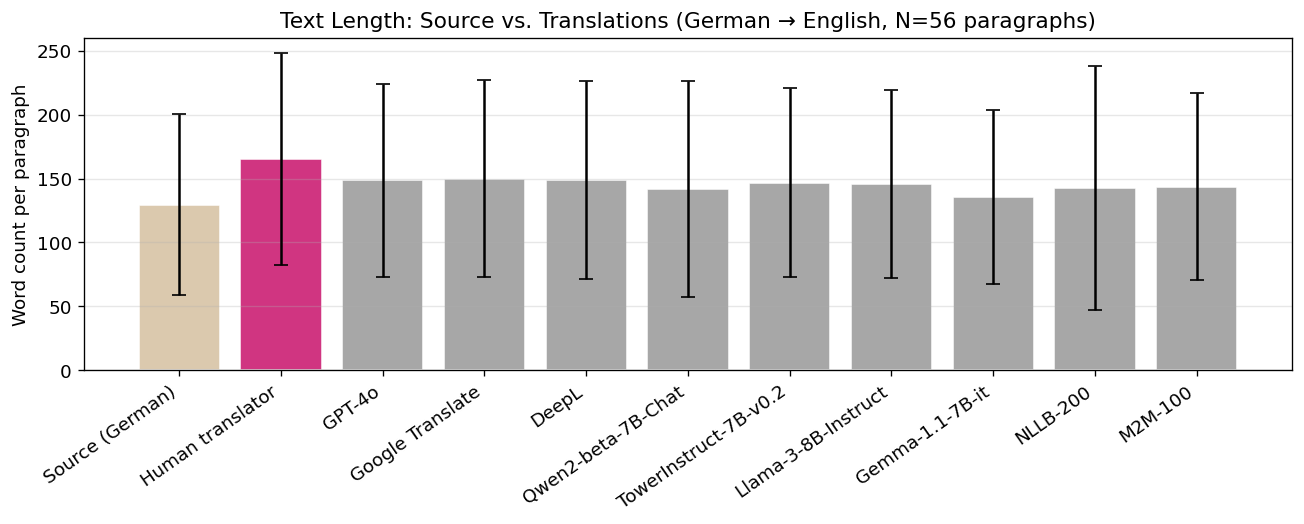

In [ ]:
def word_count(text):
    return len(str(text).split())

src_len = de_en.drop_duplicates('source').assign(n=lambda d: d['source'].apply(word_count))['n']
tgt_len_by_model = de_en.assign(n=lambda d: d['tgt'].apply(word_count)).groupby('model_norm')['n']

fig, ax = plt.subplots(figsize=(11, 4.5))
means = [src_len.mean()] + [tgt_len_by_model.mean().get(m, np.nan) for m in MODEL_ORDER]
stds = [src_len.std()] + [tgt_len_by_model.std().get(m, np.nan) for m in MODEL_ORDER]
labels = ['Source (German)'] + [MODEL_LABELS[m] for m in MODEL_ORDER]
colors = [SRC_COLOR] + [MODEL_COLORS[m] for m in MODEL_ORDER]
ax.bar(labels, means, yerr=stds, capsize=4, color=colors, alpha=0.9, edgecolor='white')
ax.set_ylabel('Word count per paragraph')
ax.set_title(f'Text Length: Source vs. Translations (German → English, N={de_en.source.nunique()} paragraphs)')
ax.tick_params(axis='x', rotation=35)
for tick in ax.get_xticklabels():
    tick.set_ha('right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG}/liteval_text_length_deen.png', dpi=300, bbox_inches='tight')
plt.show()

## Human rating and MQM score by system

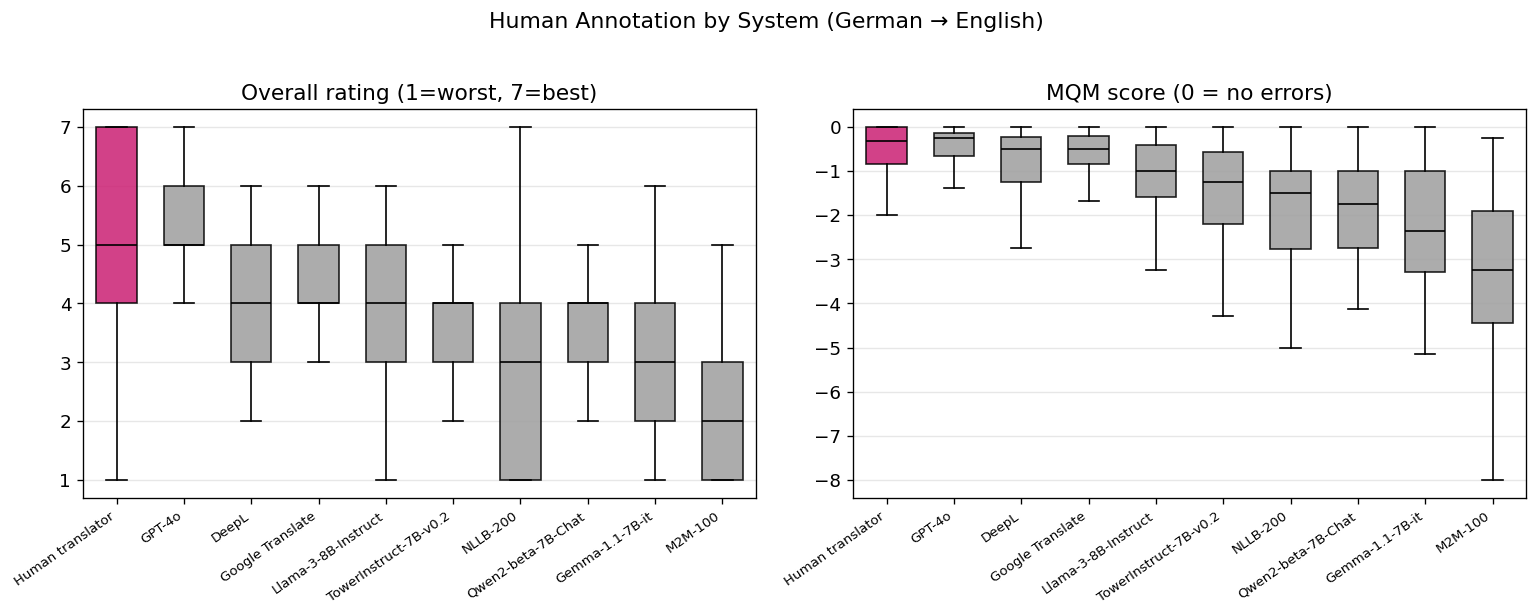

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
other_models = [m for m in de_en.model_norm.unique() if m != 'translator']
order = ['translator'] + sorted(other_models, key=lambda m: de_en[de_en.model_norm == m]['mqm_score'].median(), reverse=True)
for ax, col, title in zip(axes, ['rating', 'mqm_score'], ['Overall rating (1=worst, 7=best)', 'MQM score (0 = no errors)']):
    data = [de_en[de_en.model_norm == m][col].values for m in order]
    bp = ax.boxplot(data, patch_artist=True, widths=0.6, medianprops=dict(color='black'), showfliers=False)
    for patch, m in zip(bp['boxes'], order):
        patch.set_facecolor(MODEL_COLORS[m])
        patch.set_alpha(0.85)
    ax.set_xticks(range(1, len(order) + 1))
    ax.set_xticklabels([MODEL_LABELS[m] for m in order], rotation=35, ha='right', fontsize=8)
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('Human Annotation by System (German → English)', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG}/liteval_rating_mqm_deen.png', dpi=300, bbox_inches='tight')
plt.show()

## MQM error categories by system

Every annotated error span carries a fine-grained label (e.g. `Acc-Mistranslation`, `Style-Register`, `Fluency-coherence`). These are grouped into the four MQM top-level categories plus an "Other" bucket (locale convention, non-translation, untranslated source)

In [9]:
# Compute MQM error category counts and rates for German→English
def parse_json_field(x):
    if pd.isna(x):
        return None
    try:
        return json.loads(x)
    except Exception:
        try:
            return ast.literal_eval(x)
        except Exception:
            return None

# Map MQM error labels to broader categories
CATEGORY_MAP = {'Acc': 'Accuracy', 'Fluency': 'Fluency', 'Style': 'Style', 'Terminology': 'Terminology'}
def top_category(label):
    return CATEGORY_MAP.get(label.split('-')[0], 'Other')

# Compute error category counts and rates for German -> English
err_rows = []
for _, r in de_en.dropna(subset=['label']).iterrows():
    spans = parse_json_field(r['label'])
    if not spans:
        continue
    for sp in spans:
        for lab in sp.get('labels', []):
            err_rows.append({'model': r['model_norm'], 'category': top_category(lab)})

err_df = pd.DataFrame(err_rows)

print(f"Total error spans (German→English): {len(err_df)}")

Total error spans (German→English): 2355


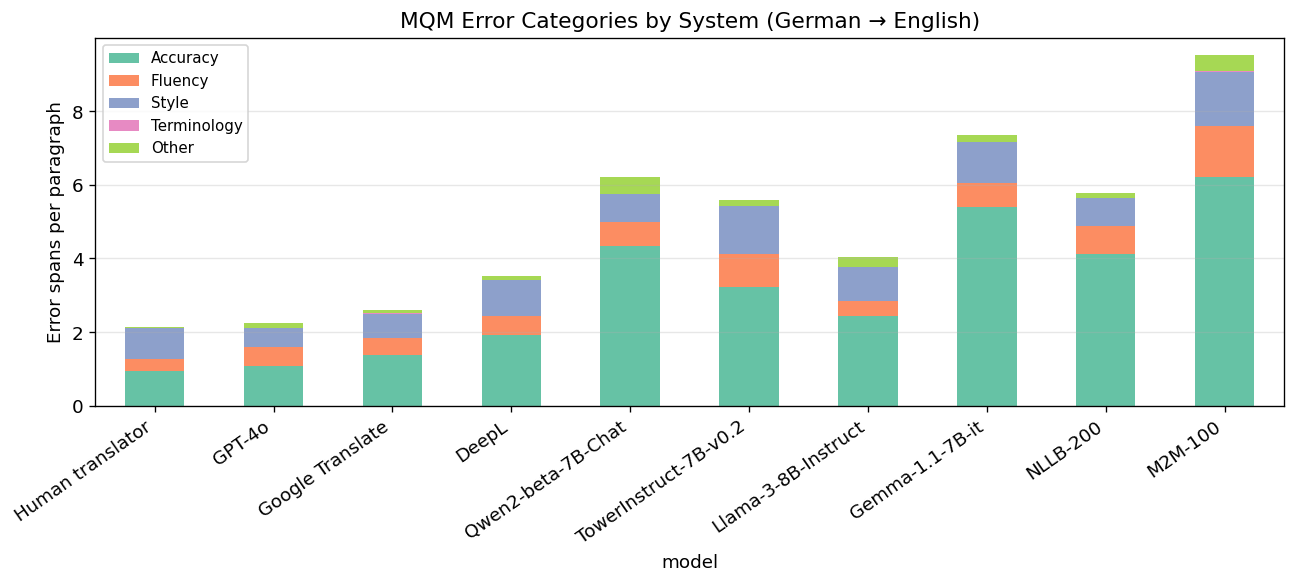

In [10]:
# Compute error category counts and rates for German -> English
cat_counts = err_df.groupby(['model', 'category']).size().unstack(fill_value=0)
cat_counts = cat_counts.reindex(index=[m for m in MODEL_ORDER if m in cat_counts.index],
                                  columns=['Accuracy', 'Fluency', 'Style', 'Terminology', 'Other'], fill_value=0)
n_par = de_en.groupby('model_norm').size()
cat_rate = cat_counts.div(n_par.reindex(cat_counts.index), axis=0)



fig, ax = plt.subplots(figsize=(11, 5))
cat_rate.plot(kind='bar', stacked=True, ax=ax, color=sns.color_palette('Set2', n_colors=5))
ax.set_ylabel('Error spans per paragraph')
ax.set_title('MQM Error Categories by System (German → English)')
ax.set_xticklabels([MODEL_LABELS[m] for m in cat_rate.index], rotation=35, ha='right')
ax.legend(title=None, fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG}/liteval_error_categories_deen.png', dpi=300, bbox_inches='tight')
plt.show()

## Inter-annotator agreement

A small subsample (4 source paragraphs x up to 12 systems) was independently annotated by two students, following the corpus's own `agreement.py` methodology

In [11]:
# Compute inter-annotator agreement for German -> English
agree = pd.read_csv(f'{CORPUS}/agreement/agreement_check - de-en.csv')[['source', 'annotator', 'rating', 'mqm_score', 'model']]
agree_p = pd.pivot(agree, index=['source', 'model'], columns=['annotator']).reset_index()
agree_p.columns = ['source_', 'model', 'rating1', 'rating2', 'mqm_score1', 'mqm_score2']
agree_p = agree_p.dropna()
kt_mqm = agree_p[['mqm_score1', 'mqm_score2']].corr(method='kendall').iloc[0, 1]
kt_rating = agree_p[['rating1', 'rating2']].corr(method='kendall').iloc[0, 1]


print(f"Kendall's tau (n={len(agree_p)}): mqm_score={kt_mqm:.2f}, rating={kt_rating:.2f}")

Kendall's tau (n=45): mqm_score=0.46, rating=0.45


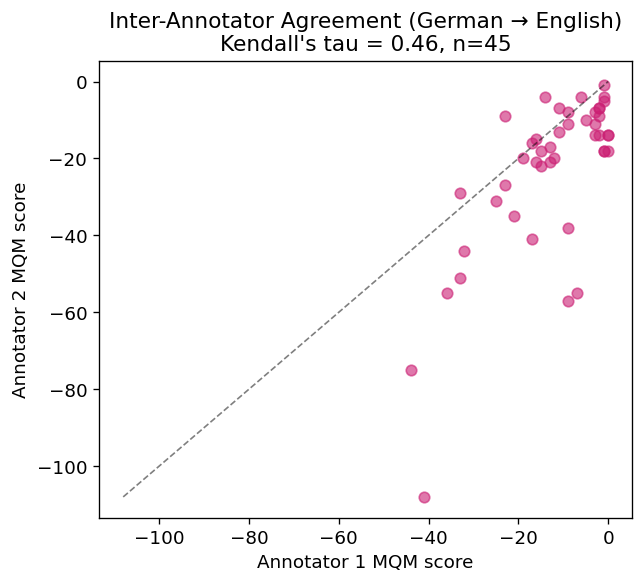

In [13]:
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(agree_p.mqm_score1, agree_p.mqm_score2, alpha=0.6, color=HT_COLOR, s=40)
lims = [agree_p[['mqm_score1', 'mqm_score2']].min().min(), agree_p[['mqm_score1', 'mqm_score2']].max().max()]
ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.5)
ax.set_xlabel('Annotator 1 MQM score')
ax.set_ylabel('Annotator 2 MQM score')
ax.set_title(f"Inter-Annotator Agreement (German → English)\nKendall's tau = {kt_mqm:.2f}, n={len(agree_p)}")
plt.tight_layout()
plt.savefig(f'{FIG}/liteval_agreement_deen.png', dpi=300, bbox_inches='tight')
plt.show()

## How often does the human translation win?

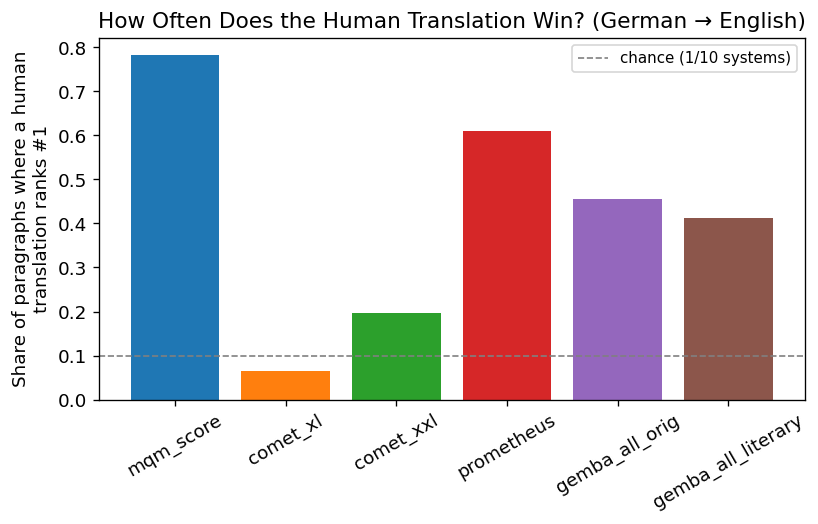

In [14]:
metric_de_en = metric_df_sample[metric_df_sample.pair == 'de-en']

# Compute the share of paragraphs where the human translation ranks #1 for each metric
def best_rank_share(df, score_col):
    results = []
    for src, group in df.groupby('source_'):
        if 'translator' not in group.model_human.values:
            continue
        ranks = group[score_col].rank(ascending=False, method='min')
        results.append(ranks[group.model_human == 'translator'].min() == 1)
    return np.mean(results)

score_cols = ['mqm_score', 'comet_xl', 'comet_xxl', 'prometheus', 'gemba_all_orig', 'gemba_all_literary']
shares = {col: best_rank_share(metric_de_en, col) for col in score_cols}


fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(list(shares.keys()), list(shares.values()), color=sns.color_palette('tab10', len(shares)))
ax.axhline(1/10, color='gray', linestyle='--', linewidth=1, label='chance (1/10 systems)')
ax.set_ylabel('Share of paragraphs where a human\ntranslation ranks #1')
ax.set_title('How Often Does the Human Translation Win? (German → English)')
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG}/liteval_human_wins_deen.png', dpi=300, bbox_inches='tight')
plt.show()

## Agreement between automatic metrics/LLM-judges and human MQM

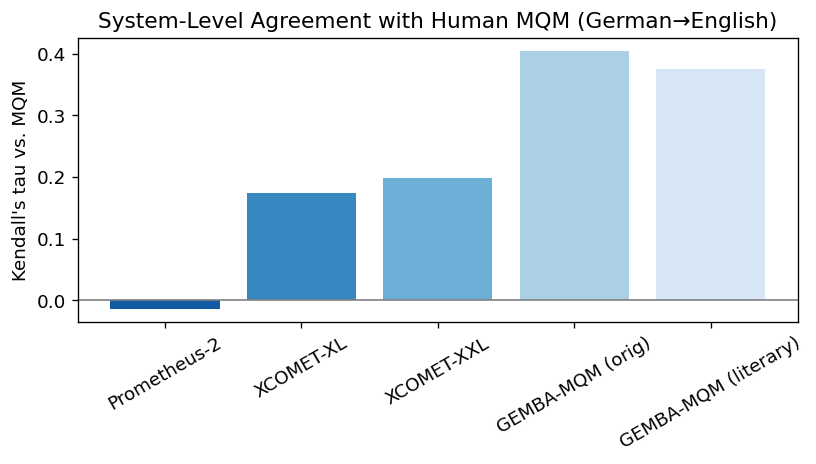

In [ ]:
target_score = ['mqm_score', 'comet_xl', 'comet_xxl', 'prometheus', 'gemba_all_orig', 'gemba_all_literary']
d1 = metric_de_en.groupby('model_id')[target_score].mean()
corr = d1.corr(method='kendall').loc[['mqm_score'], ['prometheus', 'comet_xl', 'comet_xxl', 'gemba_all_orig', 'gemba_all_literary']]
corr.columns = ['Prometheus-2', 'XCOMET-XL', 'XCOMET-XXL', 'GEMBA-MQM (orig)', 'GEMBA-MQM (literary)']

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(corr.columns, corr.iloc[0].values, color=sns.color_palette('Blues_r', len(corr.columns)))
ax.axhline(0, color='gray', linewidth=1)
ax.set_ylabel("Kendall's tau vs. MQM")
ax.set_title('System-Level Agreement with Human MQM (German → English)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(f'{FIG}/liteval_metric_correlation_deen.png', dpi=300, bbox_inches='tight')
plt.show()

## MQM vs. GEMBA-MQM agreement by aspect

Both MQM and the literary-prompted GEMBA-MQM judge break their score into accuracy/fluency/style/terminology sub-scores

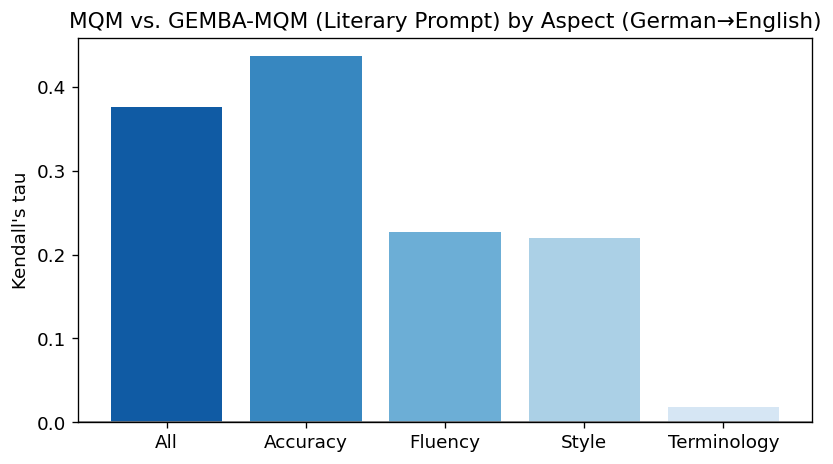

In [16]:
mqm_cols = ['mqm_score', 'mqm_score_acc', 'mqm_score_fluency', 'mqm_score_style', 'mqm_score_term']
gemba_cols = ['gemba_all_literary', 'gemba_acc_literary', 'gemba_flu_literary', 'gemba_sty_literary', 'gemba_term_literary']
d1 = metric_de_en.groupby('model_id')[mqm_cols + gemba_cols].mean()
asp_corr = [d1[[mc, gc]].corr(method='kendall').iloc[0, 1] for mc, gc in zip(mqm_cols, gemba_cols)]
asp_labels = ['All', 'Accuracy', 'Fluency', 'Style', 'Terminology']

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(asp_labels, asp_corr, color=sns.color_palette('Blues_r', len(asp_labels)))
ax.axhline(0, color='gray', linewidth=1)
ax.set_ylabel("Kendall's tau")
ax.set_title('MQM vs. GEMBA-MQM (Literary Prompt) by Aspect (German→English)')
plt.tight_layout()
plt.savefig(f'{FIG}/liteval_aspect_correlation_deen.png', dpi=300, bbox_inches='tight')
plt.show()

## Summary table

Mean rating and MQM score per system, German→English.

In [18]:
summary = de_en.groupby('model_norm')[['rating', 'mqm_score']].mean().reindex(MODEL_ORDER)
summary.index = [MODEL_LABELS[m] for m in summary.index]
summary.columns = ['Mean rating (1–7)', 'Mean MQM score']
summary.to_csv(f'{FIG}/liteval_summary_table_deen.csv')
display(summary.round(2).style.set_caption('Mean rating and MQM score by system (German -> English)'))

,Mean rating (1–7),Mean MQM score
Human translator,5.160000,-0.540000
GPT-4o,5.040000,-0.640000
Google Translate,4.260000,-0.800000
DeepL,4.150000,-1.120000
Qwen2-beta-7B-Chat,3.500000,-2.120000
TowerInstruct-7B-v0.2,3.480000,-1.720000
Llama-3-8B-Instruct,3.830000,-1.230000
Gemma-1.1-7B-it,3.150000,-2.800000
NLLB-200,2.700000,-2.770000
M2M-100,2.040000,-3.850000
